# EDA — Cell Instance Segmentation Dataset

Analysis of train (209 images) and test (101 images) splits.  
Each train sample is a folder containing `image.tif` (4-channel uint8) and instance mask files `class{1-4}.tif` (float64, pixel value = instance ID).  
Test data consists of individual `.tif` files with no annotations.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

DATA_DIR   = Path('../data')
TRAIN_DIR  = DATA_DIR / 'train'
TEST_DIR   = DATA_DIR / 'test_release'
TEST_JSON  = DATA_DIR / 'test_image_name_to_ids.json'

OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES       = [1, 2, 3, 4]
CLASS_COLORS  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
CLASS_LABELS  = [f'Class {i}' for i in CLASSES]

## 1. Collect metadata

In [2]:
def get_instance_areas(mask_path):
    """Return pixel area of every instance in the mask."""
    mask = tifffile.imread(str(mask_path))
    return [int((mask == uid).sum()) for uid in np.unique(mask[mask > 0])]

train_records = []
train_ids     = sorted(os.listdir(TRAIN_DIR))

for sid in tqdm(train_ids, desc='Scanning train'):
    d   = TRAIN_DIR / sid
    img = tifffile.imread(str(d / 'image.tif'))
    h, w = img.shape[:2]
    rec = {'id': sid, 'height': h, 'width': w,
           'area': h * w, 'aspect_ratio': w / h}
    # per-channel intensity statistics
    for ci in range(4):
        rec[f'ch{ci}_mean'] = float(img[..., ci].mean())
        rec[f'ch{ci}_std']  = float(img[..., ci].std())
    present = []
    for cls in CLASSES:
        mp = d / f'class{cls}.tif'
        if mp.exists():
            areas = get_instance_areas(mp)
            rec[f'class{cls}_n']           = len(areas)
            rec[f'class{cls}_area_mean']   = float(np.mean(areas))   if areas else 0.0
            rec[f'class{cls}_area_median'] = float(np.median(areas)) if areas else 0.0
            present.append(cls)
        else:
            rec[f'class{cls}_n']           = 0
            rec[f'class{cls}_area_mean']   = np.nan
            rec[f'class{cls}_area_median'] = np.nan
    rec['present_classes']  = tuple(sorted(present))
    rec['total_instances']  = sum(rec[f'class{c}_n'] for c in CLASSES)
    train_records.append(rec)

train_df = pd.DataFrame(train_records)
print(f'Train samples: {len(train_df)}')
train_df.head(3)

Scanning train: 100%|██████████| 209/209 [00:49<00:00,  4.26it/s]

Train samples: 209


,id,height,width,area,aspect_ratio,ch0_mean,ch0_std,ch1_mean,ch1_std,ch2_mean,...,class2_area_mean,class2_area_median,class3_n,class3_area_mean,class3_area_median,class4_n,class4_area_mean,class4_area_median,present_classes,total_instances
0,0088d6cd-fcbd-4037-babf-74abd3c82204,560,600,336000,1.071429,171.127304,40.808476,131.187744,54.066803,176.602955,...,164.50000,164.5,0,NaN,NaN,0,NaN,NaN,"(1, 2)",131
1,013c63ee-de86-4fda-b195-041a4a303b2c,1024,1024,1048576,1.000000,145.261565,30.486848,101.193299,38.231419,168.845667,...,275.70000,276.5,0,NaN,NaN,0,NaN,NaN,"(1, 2)",302
2,02f598d8-f42b-4281-84a0-37df9f4473e9,788,636,501168,0.807107,179.582651,51.383240,156.714034,61.570808,193.822618,...,274.50173,265.0,1,405.0,405.0,0,NaN,NaN,"(1, 2, 3)",311


In [3]:
with open(TEST_JSON) as f:
    test_meta = json.load(f)

test_records = []
for entry in tqdm(test_meta, desc='Scanning test'):
    fname = entry['file_name']
    img   = tifffile.imread(str(TEST_DIR / fname))
    h, w  = img.shape[:2]
    rec   = {'file_name': fname, 'id': entry['id'],
             'height': h, 'width': w,
             'area': h * w, 'aspect_ratio': w / h}
    # number of channels may vary; iterate dynamically
    for ci in range(img.shape[2] if img.ndim == 3 else 1):
        ch = img[..., ci] if img.ndim == 3 else img
        rec[f'ch{ci}_mean'] = float(ch.mean())
        rec[f'ch{ci}_std']  = float(ch.std())
    test_records.append(rec)

test_df = pd.DataFrame(test_records)
print(f'Test samples: {len(test_df)}')
test_df.head(3)

Scanning test: 100%|██████████| 101/101 [00:03<00:00, 27.50it/s]

Test samples: 101


,file_name,id,height,width,area,aspect_ratio,ch0_mean,ch0_std,ch1_mean,ch1_std,ch2_mean,ch2_std,ch3_mean,ch3_std
0,c8cb7626-7423-4c1e-a81c-5ff25ea180b3.tif,1,446,512,228352,1.147982,173.215671,27.215545,136.920303,35.388611,187.234195,38.203593,255.0,0.0
1,8bf17017-577c-4bc7-b599-df8289a69279.tif,2,151,147,22197,0.973510,187.127224,37.589379,161.365455,47.991421,208.929765,43.208486,255.0,0.0
2,acaf16a8-d1e6-4746-92ae-c76fa82cb70d.tif,3,384,497,190848,1.294271,199.335476,33.403695,182.457673,40.749688,220.454220,29.456132,255.0,0.0


## 2. Dataset overview

In [4]:
class_totals = [train_df[f'class{c}_n'].sum() for c in CLASSES]

print('=' * 55)
print(f'  Train : {len(train_df)} images | Test : {len(test_df)} images')
print()
print('Class presence in train:')
for cls in CLASSES:
    n = (train_df[f'class{cls}_n'] > 0).sum()
    print(f'  class{cls}: {n}/{len(train_df)} images ({n/len(train_df)*100:.1f}%)')
print()
print('Total instances per class:')
for cls, total in zip(CLASSES, class_totals):
    pct = total / sum(class_totals) * 100
    print(f'  class{cls}: {total:6,} ({pct:.1f}%)')
print(f'  TOTAL : {sum(class_totals):,}')
print('=' * 55)

  Train : 209 images | Test : 101 images

Class presence in train:
  class1: 96/209 images (45.9%)
  class2: 146/209 images (69.9%)
  class3: 94/209 images (45.0%)
  class4: 58/209 images (27.8%)

Total instances per class:
  class1: 14,537 (46.3%)
  class2: 15,653 (49.8%)
  class3:    630 (2.0%)
  class4:    587 (1.9%)
  TOTAL : 31,407


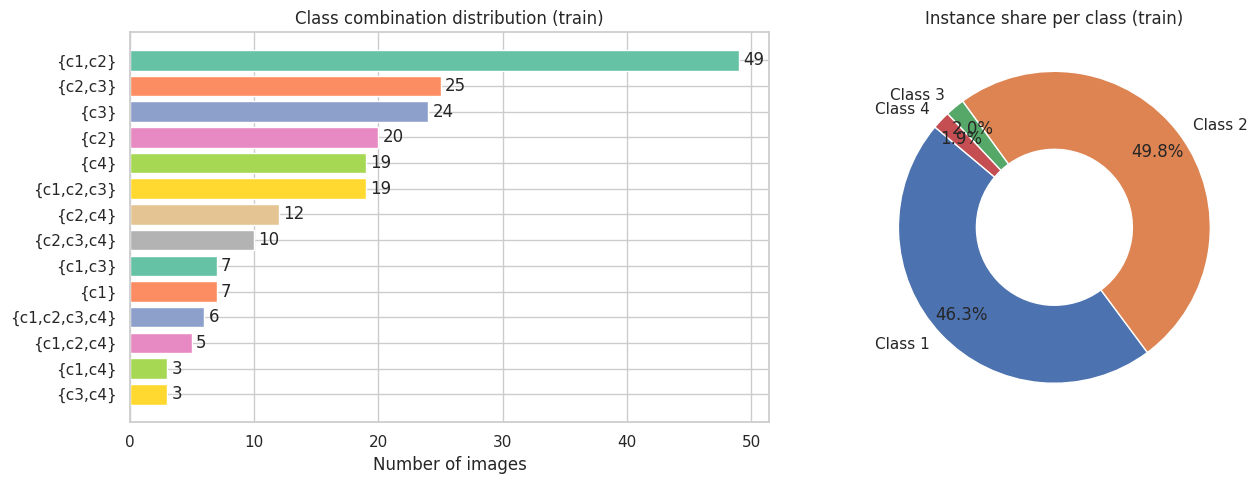

In [5]:
# Class combination distribution
combo_counts = train_df['present_classes'].value_counts().reset_index()
combo_counts.columns = ['combo', 'count']
combo_counts['label'] = combo_counts['combo'].apply(
    lambda t: '{' + ','.join(f'c{x}' for x in t) + '}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(combo_counts['label'], combo_counts['count'],
                    color=sns.color_palette('Set2', len(combo_counts)))
axes[0].bar_label(bars, padding=3)
axes[0].set_xlabel('Number of images')
axes[0].set_title('Class combination distribution (train)')
axes[0].invert_yaxis()

# Donut chart of instance share
wedges, texts, autotexts = axes[1].pie(
    class_totals, labels=CLASS_LABELS, colors=CLASS_COLORS,
    autopct='%1.1f%%', startangle=140, pctdistance=0.82,
    wedgeprops=dict(width=0.5))
axes[1].set_title('Instance share per class (train)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Image size distribution

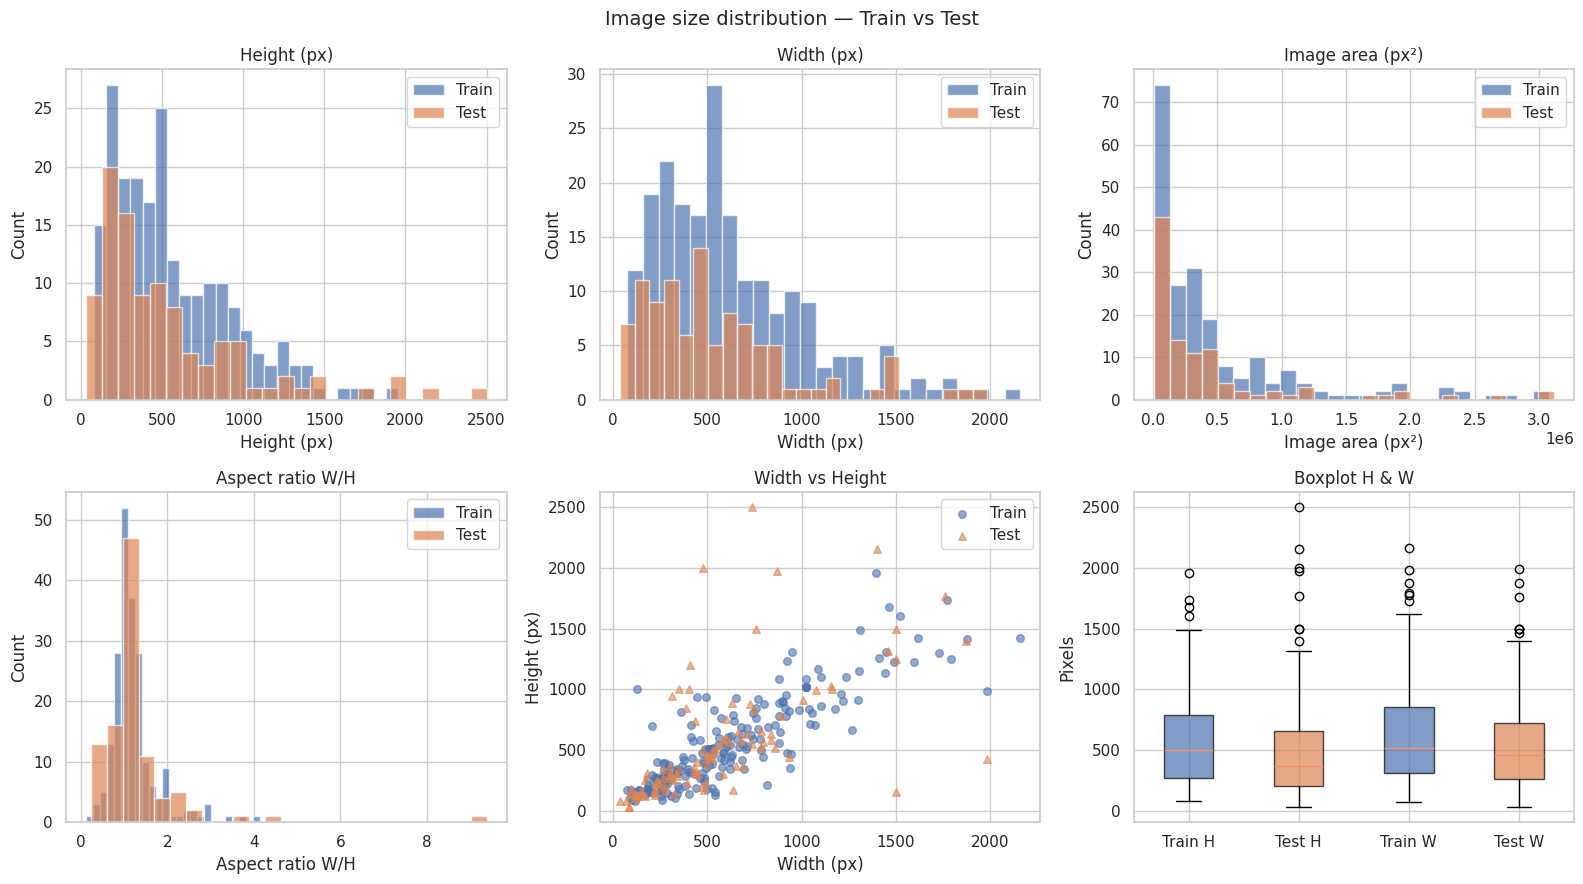


Train image size stats:
       height   width       area  aspect_ratio
count   209.0   209.0      209.0         209.0
mean    563.9   628.3   483937.0           1.2
std     371.4   410.0   618476.7           0.6
min      81.0    74.0     8820.0           0.1
25%     273.0   311.0    86880.0           0.9
50%     500.0   523.0   262144.0           1.1
75%     788.0   859.0   598176.0           1.3
max    1956.0  2162.0  3074364.0           4.1

Test image size stats:
       height   width       area  aspect_ratio
count   101.0   101.0      101.0         101.0
mean    547.9   548.7   424413.7           1.3
std     491.3   413.2   632606.4           1.0
min      33.0    35.0     2838.0           0.2
25%     206.0   264.0    56032.0           0.9
50%     374.0   464.0   209166.0           1.1
75%     655.0   726.0   448797.0           1.3
max    2500.0  1987.0  3116960.0           9.4


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Image size distribution — Train vs Test', fontsize=14)

metrics = [
    ('height',       'Height (px)'),
    ('width',        'Width (px)'),
    ('area',         'Image area (px²)'),
    ('aspect_ratio', 'Aspect ratio W/H'),
]
for ax, (col, label) in zip(axes.flat, metrics):
    ax.hist(train_df[col], bins=25, alpha=0.7, label='Train', color='#4C72B0', edgecolor='white')
    ax.hist(test_df[col],  bins=25, alpha=0.7, label='Test',  color='#DD8452', edgecolor='white')
    ax.set_xlabel(label); ax.set_ylabel('Count'); ax.set_title(label); ax.legend()

# Scatter H vs W
ax = axes[1, 1]
ax.scatter(train_df['width'], train_df['height'], alpha=0.6, s=30, label='Train', color='#4C72B0')
ax.scatter(test_df['width'],  test_df['height'],  alpha=0.6, s=30, label='Test',  color='#DD8452', marker='^')
ax.set_xlabel('Width (px)'); ax.set_ylabel('Height (px)'); ax.set_title('Width vs Height'); ax.legend()

# Boxplot comparison
ax = axes[1, 2]
data_box = [train_df['height'].values, test_df['height'].values,
            train_df['width'].values,  test_df['width'].values]
bplot = ax.boxplot(data_box, patch_artist=True,
                   labels=['Train H', 'Test H', 'Train W', 'Test W'])
for patch, color in zip(bplot['boxes'], ['#4C72B0','#DD8452','#4C72B0','#DD8452']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Pixels'); ax.set_title('Boxplot H & W')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

for name, df in [('Train', train_df), ('Test', test_df)]:
    print(f'\n{name} image size stats:')
    print(df[['height','width','area','aspect_ratio']].describe().round(1))

## 4. Instance count distribution per image (train)

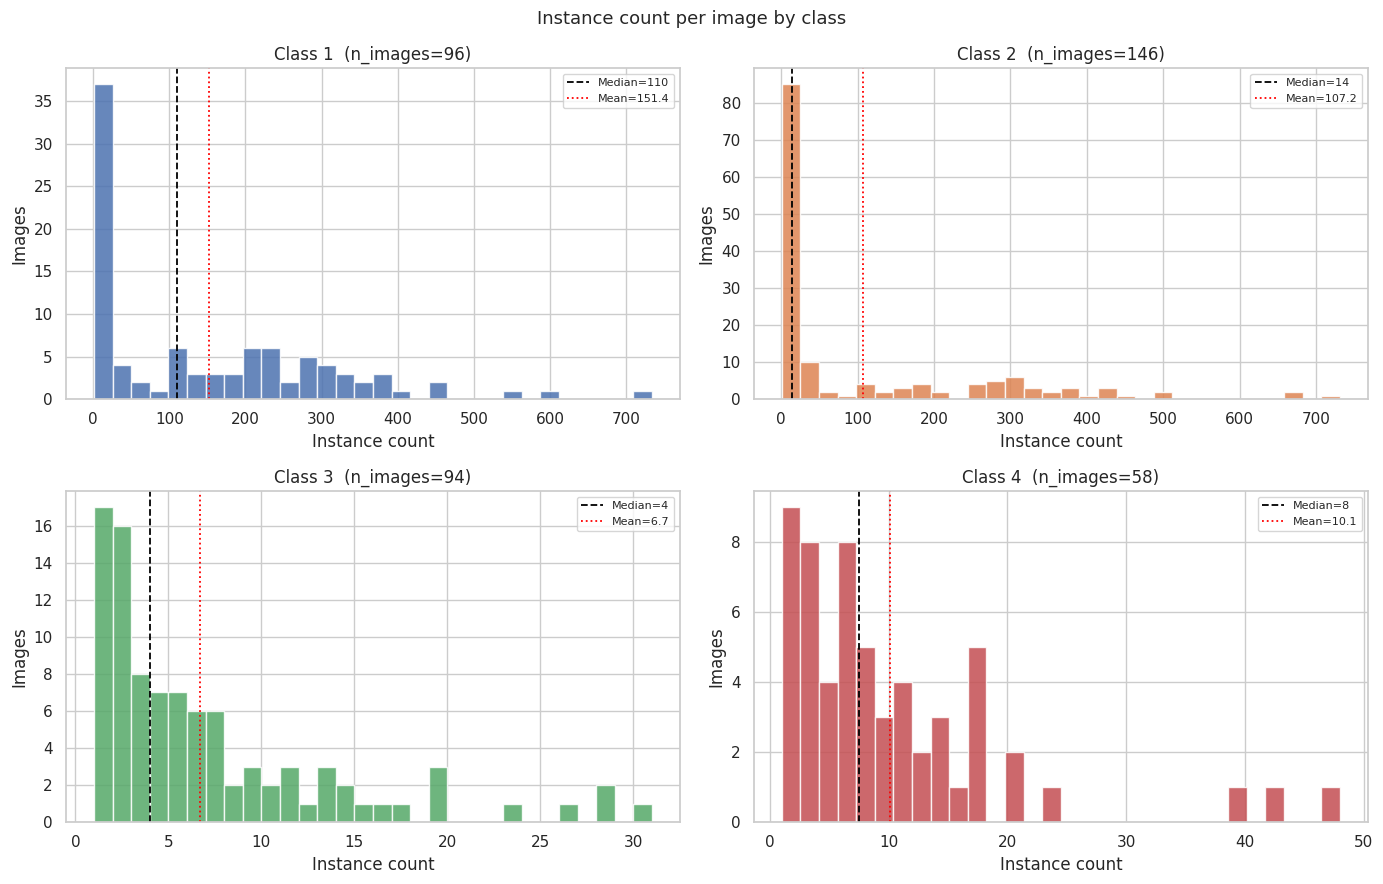

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Instance count per image by class', fontsize=13)

for ax, cls, color in zip(axes.flat, CLASSES, CLASS_COLORS):
    # only include images that actually have this class
    data = train_df.loc[train_df[f'class{cls}_n'] > 0, f'class{cls}_n']
    if len(data) == 0:
        continue
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', lw=1.3, label=f'Median={data.median():.0f}')
    ax.axvline(data.mean(),   color='red',   linestyle=':',  lw=1.3, label=f'Mean={data.mean():.1f}')
    ax.set_title(f'Class {cls}  (n_images={len(data)})')
    ax.set_xlabel('Instance count'); ax.set_ylabel('Images'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_instance_count_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

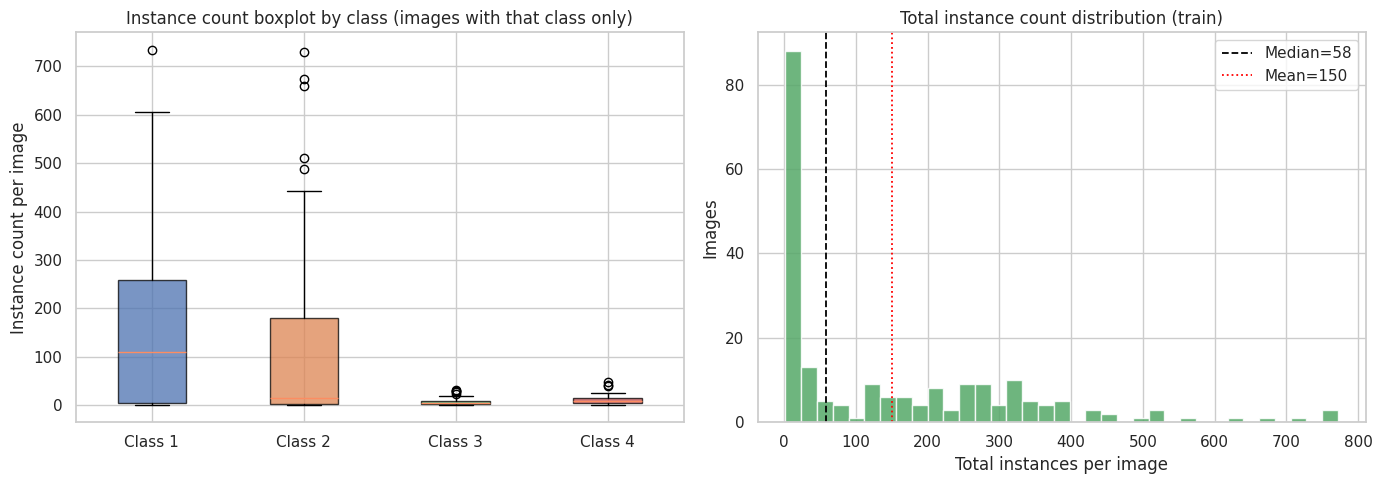


Instance count stats per class (images that have that class):
  Class 1: n_images= 96  min=   1  median=   110  mean= 151.4  max=  734
  Class 2: n_images=146  min=   1  median=    14  mean= 107.2  max=  731
  Class 3: n_images= 94  min=   1  median=     4  mean=   6.7  max=   31
  Class 4: n_images= 58  min=   1  median=     8  mean=  10.1  max=   48


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot per class (images that have that class)
data_all = [train_df.loc[train_df[f'class{c}_n'] > 0, f'class{c}_n'].values for c in CLASSES]
bplot = axes[0].boxplot(data_all, patch_artist=True, labels=CLASS_LABELS)
for patch, color in zip(bplot['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_ylabel('Instance count per image')
axes[0].set_title('Instance count boxplot by class (images with that class only)')

# Total instances per image histogram
axes[1].hist(train_df['total_instances'], bins=35, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(train_df['total_instances'].median(), color='black', linestyle='--', lw=1.3,
                label=f'Median={train_df["total_instances"].median():.0f}')
axes[1].axvline(train_df['total_instances'].mean(), color='red', linestyle=':', lw=1.3,
                label=f'Mean={train_df["total_instances"].mean():.0f}')
axes[1].set_xlabel('Total instances per image'); axes[1].set_ylabel('Images')
axes[1].set_title('Total instance count distribution (train)'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_instance_count_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInstance count stats per class (images that have that class):')
for cls in CLASSES:
    d = train_df.loc[train_df[f'class{cls}_n'] > 0, f'class{cls}_n']
    print(f'  Class {cls}: n_images={len(d):3d}  min={d.min():4.0f}  '
          f'median={d.median():6.0f}  mean={d.mean():6.1f}  max={d.max():5.0f}')

## 5. Instance area distribution (px²)

In [9]:
# Collect pixel areas for every instance across all train images
all_areas = {cls: [] for cls in CLASSES}

for sid in tqdm(train_ids, desc='Collecting instance areas'):
    d = TRAIN_DIR / sid
    for cls in CLASSES:
        mp = d / f'class{cls}.tif'
        if mp.exists():
            mask = tifffile.imread(str(mp))
            for uid in np.unique(mask[mask > 0]):
                all_areas[cls].append(int((mask == uid).sum()))

for cls in CLASSES:
    print(f'Class {cls}: {len(all_areas[cls]):,} instances')

Class 1: 14,537 instances
Class 2: 15,653 instances
Class 3: 630 instances
Class 4: 587 instances


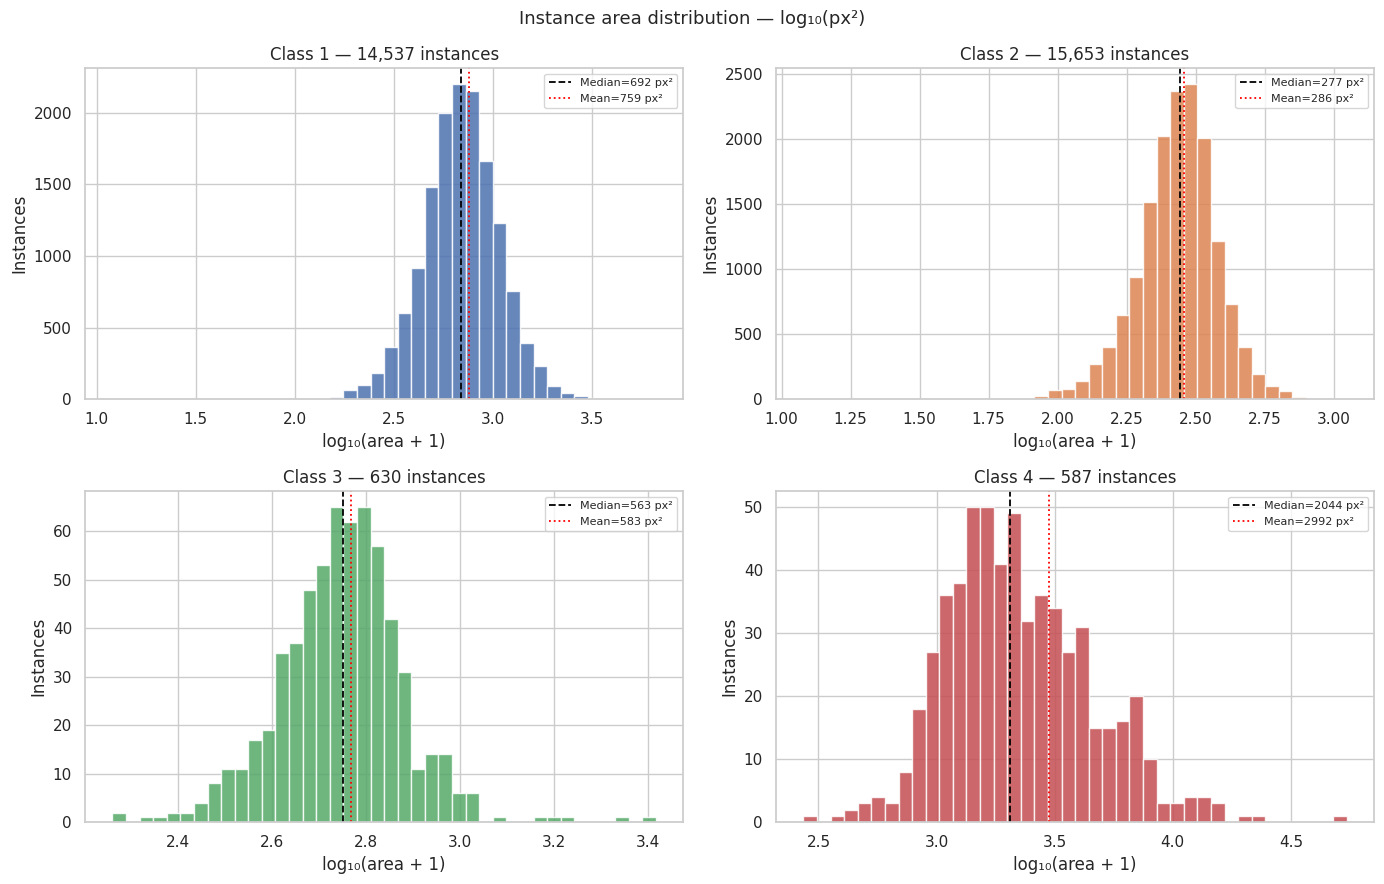

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Instance area distribution — log₁₀(px²)', fontsize=13)

for ax, cls, color in zip(axes.flat, CLASSES, CLASS_COLORS):
    areas = np.array(all_areas[cls])
    if not len(areas):
        continue
    ax.hist(np.log10(areas + 1), bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.log10(np.median(areas) + 1), color='black', linestyle='--', lw=1.3,
               label=f'Median={np.median(areas):.0f} px²')
    ax.axvline(np.log10(areas.mean() + 1),     color='red',   linestyle=':',  lw=1.3,
               label=f'Mean={areas.mean():.0f} px²')
    ax.set_xlabel('log₁₀(area + 1)')
    ax.set_ylabel('Instances')
    ax.set_title(f'Class {cls} — {len(areas):,} instances')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_instance_area_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

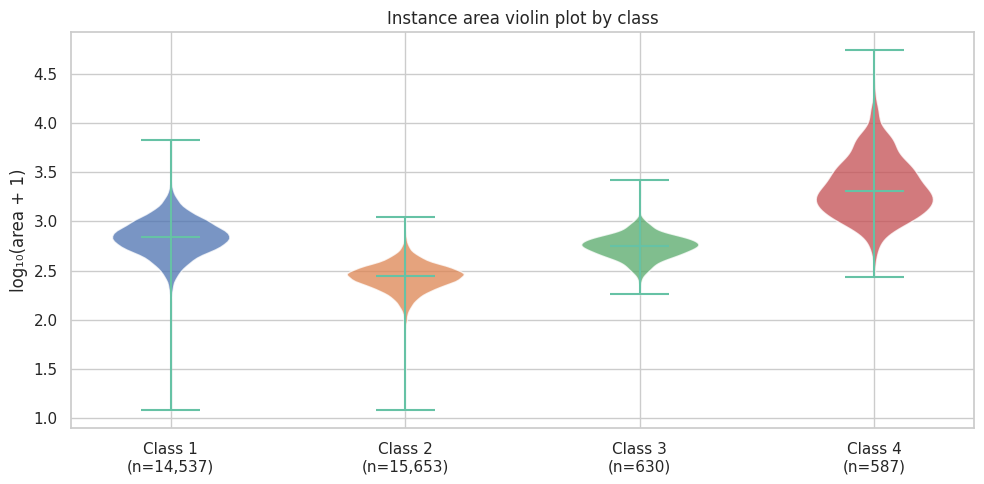

Instance area stats (px²):
  Class 1: min=   11  p25=    525  median=    692  mean=    759  p75=    918  max=   6652
  Class 2: min=   11  p25=    225  median=    277  mean=    286  p75=    334  max=   1115
  Class 3: min=  181  p25=    467  median=    563  mean=    583  p75=    666  max=   2608
  Class 4: min=  272  p25=   1358  median=   2044  mean=   2992  p75=   3472  max=  54554


In [11]:
# Violin plot comparing all classes side by side
area_data  = [np.log10(np.array(all_areas[c]) + 1) for c in CLASSES if all_areas[c]]
area_lbls  = [f'Class {c}\n(n={len(all_areas[c]):,})' for c in CLASSES if all_areas[c]]

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(area_data, showmedians=True)
for pc, color in zip(parts['bodies'], CLASS_COLORS):
    pc.set_facecolor(color); pc.set_alpha(0.75)
ax.set_xticks(range(1, len(area_lbls)+1))
ax.set_xticklabels(area_lbls)
ax.set_ylabel('log₁₀(area + 1)')
ax.set_title('Instance area violin plot by class')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_instance_area_violin.png', dpi=150, bbox_inches='tight')
plt.show()

print('Instance area stats (px²):')
for cls in CLASSES:
    a = np.array(all_areas[cls])
    if len(a):
        print(f'  Class {cls}: min={a.min():5d}  p25={np.percentile(a,25):7.0f}  '
              f'median={np.median(a):7.0f}  mean={a.mean():7.0f}  '
              f'p75={np.percentile(a,75):7.0f}  max={a.max():7d}')

## 6. Channel intensity distribution — Train vs Test

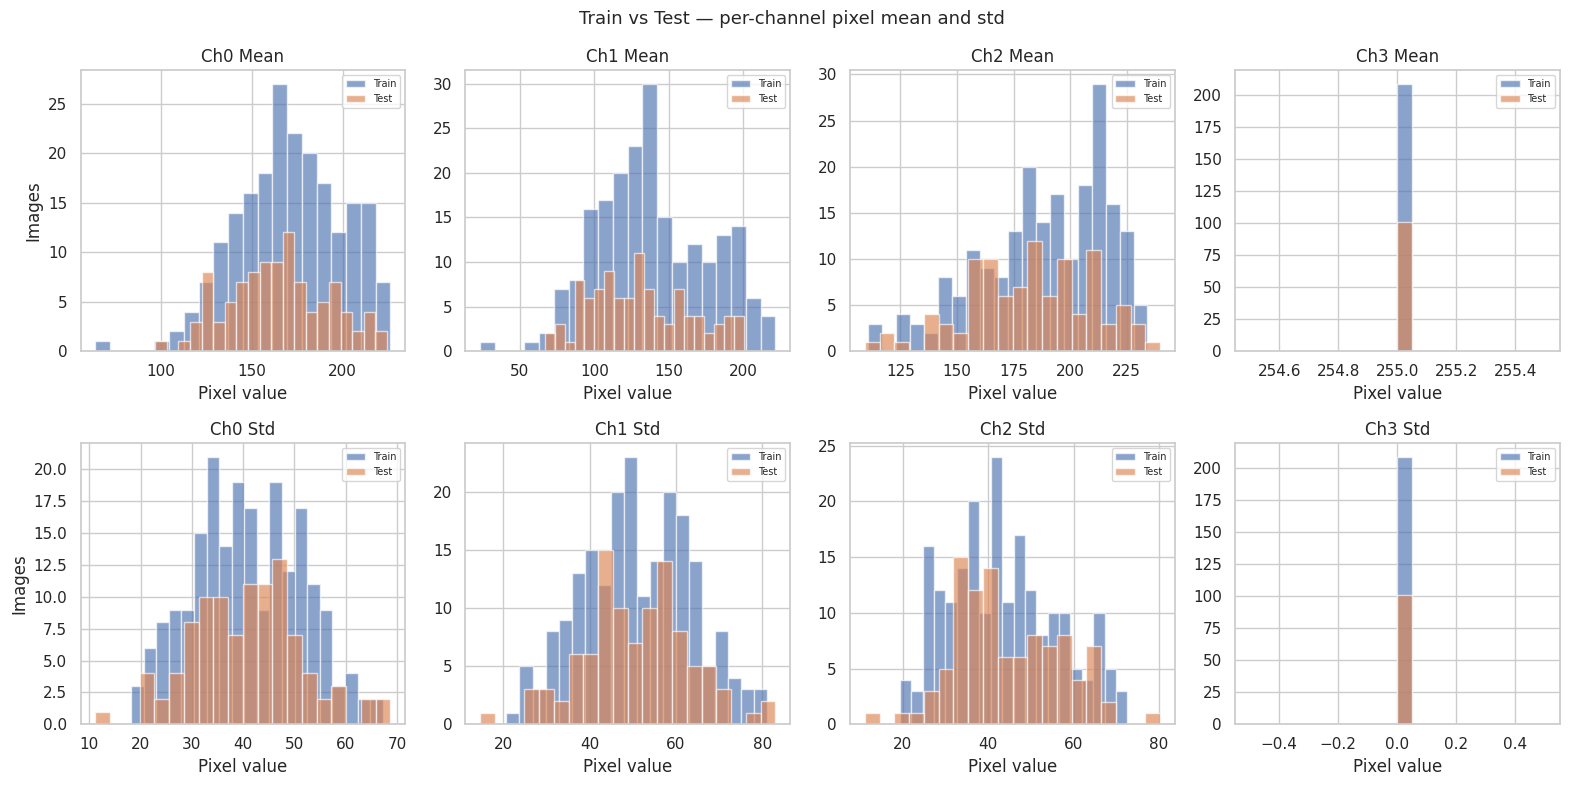

Mean    Std     Min     Max
Channel Split                               
Ch0     Train  170.86  28.83   64.00  226.32
        Test   164.84  27.79   96.97  224.38
Ch1     Train  139.36  37.16   23.36  221.38
        Test   130.79  33.40   66.61  200.45
Ch2     Train  189.04  27.73  110.76  234.22
        Test   182.72  27.53  109.31  239.83
Ch3     Train  255.00   0.00  255.00  255.00
        Test   255.00   0.00  255.00  255.00

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Train vs Test — per-channel pixel mean and std', fontsize=13)

for ci in range(4):
    for row, metric in enumerate(['mean', 'std']):
        col = f'ch{ci}_{metric}'
        ax  = axes[row, ci]
        tr  = train_df[col].dropna() if col in train_df else pd.Series(dtype=float)
        te  = test_df[col].dropna()  if col in test_df  else pd.Series(dtype=float)
        ax.hist(tr, bins=20, alpha=0.65, label='Train', color='#4C72B0', edgecolor='white')
        ax.hist(te, bins=20, alpha=0.65, label='Test',  color='#DD8452', edgecolor='white')
        ax.set_title(f'Ch{ci} {metric.capitalize()}')
        ax.set_xlabel('Pixel value')
        if ci == 0: ax.set_ylabel('Images')
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_channel_intensity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
rows = []
for ci in range(4):
    for split, df in [('Train', train_df), ('Test', test_df)]:
        col = f'ch{ci}_mean'
        if col not in df: continue
        d = df[col].dropna()
        rows.append({'Channel': f'Ch{ci}', 'Split': split,
                     'Mean': d.mean(), 'Std': d.std(), 'Min': d.min(), 'Max': d.max()})
pd.DataFrame(rows).set_index(['Channel','Split']).round(2)

## 7. Correlation heatmap (train)

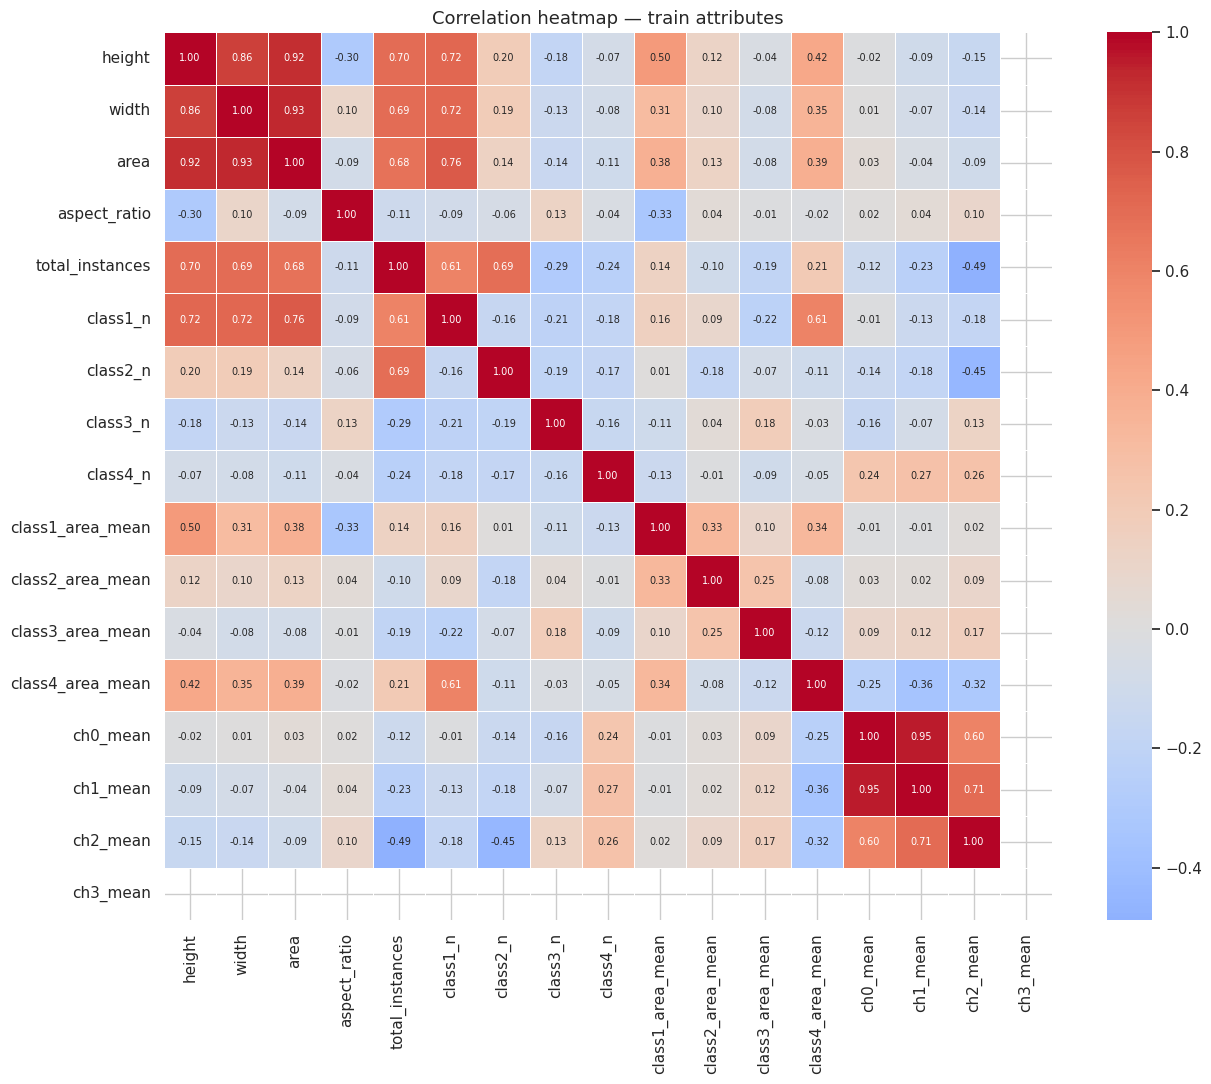

In [13]:
corr_cols = ['height','width','area','aspect_ratio','total_instances',
             'class1_n','class2_n','class3_n','class4_n',
             'class1_area_mean','class2_area_mean','class3_area_mean','class4_area_mean',
             'ch0_mean','ch1_mean','ch2_mean','ch3_mean']
corr_cols = [c for c in corr_cols if c in train_df.columns]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(train_df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation heatmap — train attributes', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sample image and mask visualisation

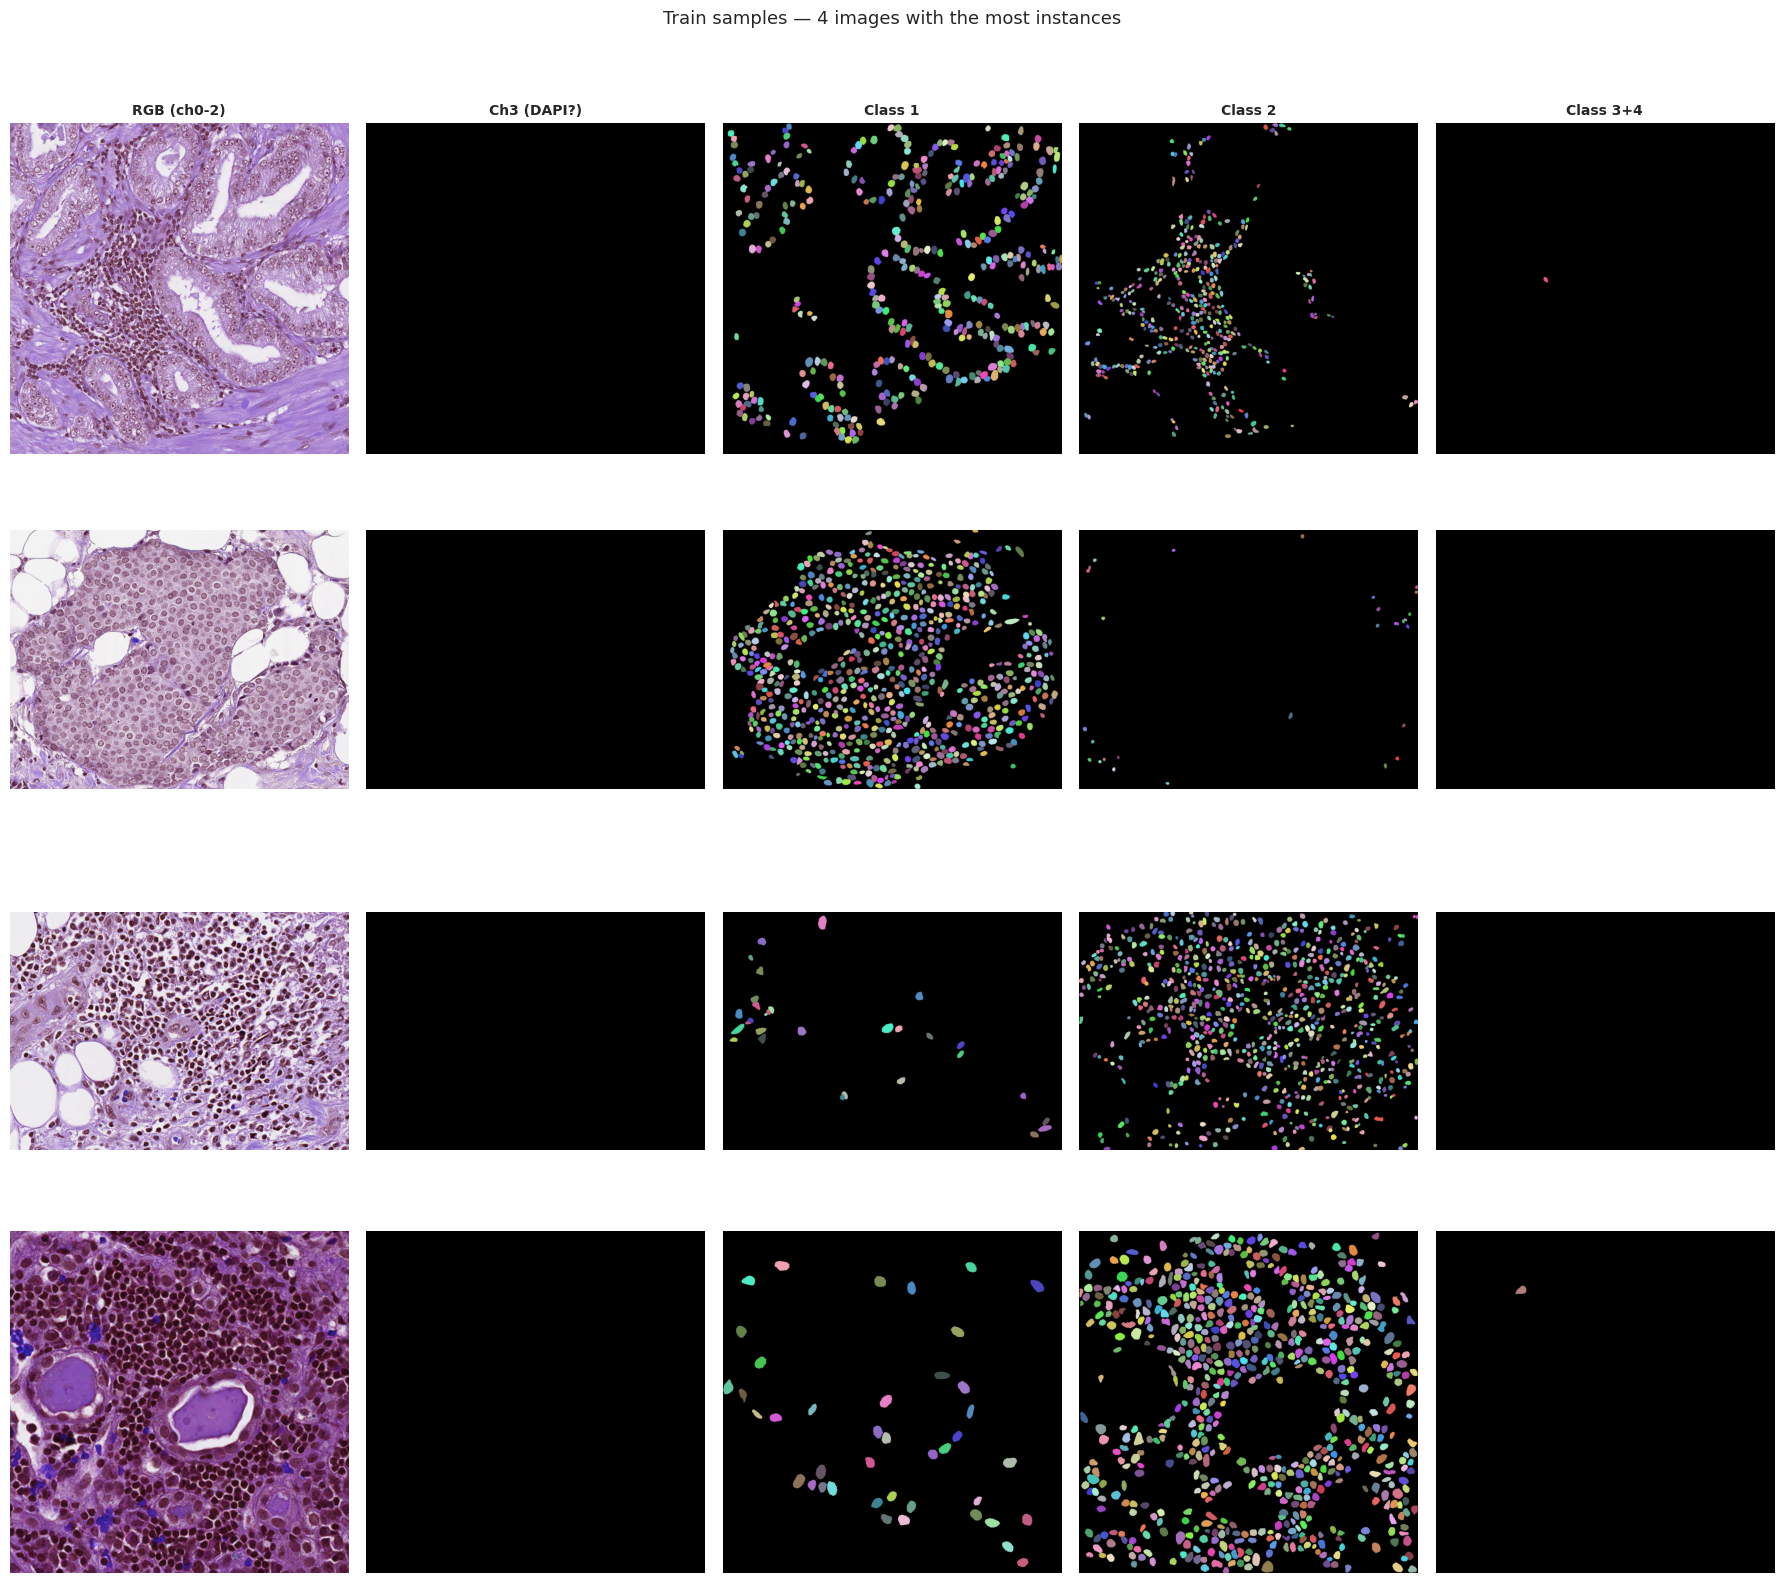

In [14]:
def colorize_mask(mask):
    """Assign a unique random color to each instance ID."""
    rng     = np.random.default_rng(42)
    palette = rng.integers(60, 240, size=(4096, 3), dtype=np.uint8)
    palette[0] = 0  # background stays black
    out = np.zeros((*mask.shape[:2], 3), dtype=np.uint8)
    for uid in np.unique(mask[mask > 0]).astype(int):
        out[mask == uid] = palette[uid % 4096]
    return out

# Pick the 4 images with the most instances
sample_ids = train_df.nlargest(4, 'total_instances')['id'].tolist()

fig, axes = plt.subplots(4, 5, figsize=(18, 16))
col_titles = ['RGB (ch0-2)', 'Ch3 (DAPI?)', 'Class 1', 'Class 2', 'Class 3+4']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=10, fontweight='bold')

for row, sid in enumerate(sample_ids):
    d   = TRAIN_DIR / sid
    img = tifffile.imread(str(d / 'image.tif'))
    axes[row, 0].imshow(img[..., :3])
    axes[row, 0].set_ylabel(sid[:12], fontsize=7)
    axes[row, 1].imshow(img[..., 3], cmap='gray')
    # merge class masks for visualisation
    for col_idx, cls_list in enumerate([[1], [2], [3, 4]], start=2):
        combined = np.zeros(img.shape[:2], dtype=float)
        for cls in cls_list:
            mp = d / f'class{cls}.tif'
            if mp.exists():
                m = tifffile.imread(str(mp))
                combined = np.where(m > 0, m, combined)
        axes[row, col_idx].imshow(colorize_mask(combined))
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Train samples — 4 images with the most instances', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_train_samples.png', dpi=150, bbox_inches='tight')
plt.show()

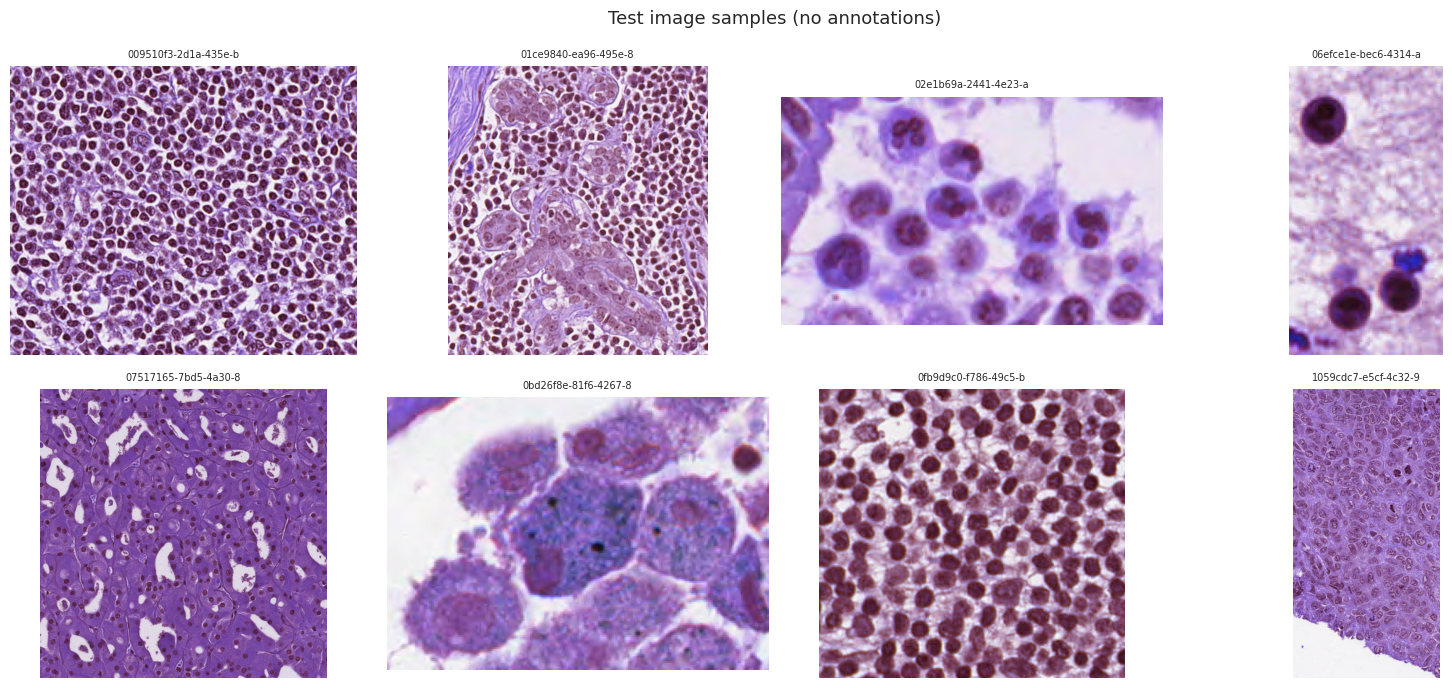

In [15]:
# Show 8 test images (no ground-truth masks)
test_files = sorted(os.listdir(TEST_DIR))[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Test image samples (no annotations)', fontsize=13)
for ax, fname in zip(axes.flat, test_files):
    img = tifffile.imread(str(TEST_DIR / fname))
    ax.imshow(img[..., :3] if img.ndim == 3 else img, cmap='gray')
    ax.set_title(fname[:20], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '10_test_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [16]:
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)
print(f'Train: {len(train_df)} images | Test: {len(test_df)} images')
print()
print('Train image size:')
print(f'  H: {train_df.height.min()}-{train_df.height.max()} px  (median={train_df.height.median():.0f})')
print(f'  W: {train_df.width.min()}-{train_df.width.max()} px  (median={train_df.width.median():.0f})')
print()
print('Test image size:')
print(f'  H: {test_df.height.min()}-{test_df.height.max()} px  (median={test_df.height.median():.0f})')
print(f'  W: {test_df.width.min()}-{test_df.width.max()} px  (median={test_df.width.median():.0f})')
print()
print('Instances (train):')
total_all = sum(class_totals)
for cls, total in zip(CLASSES, class_totals):
    imgs = (train_df[f'class{cls}_n'] > 0).sum()
    print(f'  Class {cls}: {total:6,} instances  {imgs:3d} images  ({total/total_all*100:.1f}%)')
print(f'  TOTAL : {total_all:,} instances')
print()
print('Mean instance area (px²):')
for cls in CLASSES:
    a = np.array(all_areas[cls])
    if len(a):
        print(f'  Class {cls}: median={np.median(a):.0f}  mean={a.mean():.0f}  max={a.max()}')
print('=' * 60)

EDA SUMMARY
Train: 209 images | Test: 101 images

Train image size:
  H: 81-1956 px  (median=500)
  W: 74-2162 px  (median=523)

Test image size:
  H: 33-2500 px  (median=374)
  W: 35-1987 px  (median=464)

Instances (train):
  Class 1: 14,537 instances   96 images  (46.3%)
  Class 2: 15,653 instances  146 images  (49.8%)
  Class 3:    630 instances   94 images  (2.0%)
  Class 4:    587 instances   58 images  (1.9%)
  TOTAL : 31,407 instances

Mean instance area (px²):
  Class 1: median=692  mean=759  max=6652
  Class 2: median=277  mean=286  max=1115
  Class 3: median=563  mean=583  max=2608
  Class 4: median=2044  mean=2992  max=54554


## 10. Distribution Shift — Train vs Test (PSI)

PSI (Population Stability Index) measures how much a distribution has shifted:
- PSI < 0.1: no significant shift
- 0.1 ≤ PSI < 0.2: slight shift
- PSI ≥ 0.2: **significant shift**

Reference distribution = aggregate pixel histogram of all train images (per channel).  
Each test image is compared against the reference; PSI is computed per channel.

In [17]:
import numpy as np
import tifffile
from pathlib import Path
from tqdm import tqdm

N_BINS   = 32       # number of bins for pixel value histogram
PSI_WARN = 0.1      # slight shift threshold
PSI_CRIT = 0.2      # significant shift threshold
EPS      = 1e-8     # avoid log(0)

def channel_histogram(img_3d, ch, n_bins=N_BINS):
    """Normalised pixel-value histogram for a single channel."""
    pixels = img_3d[..., ch].ravel().astype(float)
    hist, _ = np.histogram(pixels, bins=n_bins, range=(0, 256))
    return hist / (hist.sum() + EPS)

def psi(p_ref, p_cmp):
    """Population Stability Index between two normalised histograms."""
    p_ref = np.clip(p_ref, EPS, None)
    p_cmp = np.clip(p_cmp, EPS, None)
    return float(np.sum((p_cmp - p_ref) * np.log(p_cmp / p_ref)))

# --- Build reference histograms from all train images ---
ref_hists = {ch: np.zeros(N_BINS) for ch in range(4)}
n_train   = 0

for sid in tqdm(train_ids, desc='Building train reference histograms', colour='green'):
    img = tifffile.imread(str(TRAIN_DIR / sid / 'image.tif'))
    for ch in range(4):
        ref_hists[ch] += channel_histogram(img, ch)
    n_train += 1

# Average histogram across all train images
for ch in range(4):
    ref_hists[ch] /= n_train

print('Reference histograms built from', n_train, 'train images')

Building train reference histograms: 100%|██████████| 209/209 [00:12<00:00, 17.16it/s]

Reference histograms built from 209 train images


In [18]:
# --- Compute PSI for every test image ---
psi_records = []

for fname in tqdm(sorted(os.listdir(TEST_DIR)), desc='Computing PSI for test images', colour='red'):
    img  = tifffile.imread(str(TEST_DIR / fname))
    row  = {'file_name': fname}
    for ch in range(4):
        cmp_hist    = channel_histogram(img, ch)
        row[f'psi_ch{ch}'] = psi(ref_hists[ch], cmp_hist)
    row['psi_max'] = max(row[f'psi_ch{ch}'] for ch in range(4))
    row['psi_mean'] = np.mean([row[f'psi_ch{ch}'] for ch in range(4)])
    row['shifted']  = row['psi_max'] >= PSI_CRIT
    psi_records.append(row)

psi_df = pd.DataFrame(psi_records).sort_values('psi_max', ascending=False).reset_index(drop=True)

n_shifted = psi_df['shifted'].sum()
print(f'Test images with PSI >= {PSI_CRIT} (significant shift): {n_shifted}/{len(psi_df)}')
print(f'Test images with PSI >= {PSI_WARN} (slight shift):       {(psi_df["psi_max"] >= PSI_WARN).sum()}/{len(psi_df)}')
print()
psi_df[['file_name','psi_ch0','psi_ch1','psi_ch2','psi_ch3','psi_max','shifted']].head(10)

Computing PSI for test images: 100%|██████████| 101/101 [00:05<00:00, 19.42it/s]

Test images with PSI >= 0.2 (significant shift): 101/101
Test images with PSI >= 0.1 (slight shift):       101/101



,file_name,psi_ch0,psi_ch1,psi_ch2,psi_ch3,psi_max,shifted
0,e97728a0-b44d-474e-9462-0e4d02ee75e3.tif,4.306564,4.335911,5.347328,5.401774e-27,5.347328,True
1,6197235b-d09c-4893-82fc-1fbb8304fb5a.tif,3.854599,3.969549,0.417776,1.169441e-23,3.969549,True
2,e9660304-f3cb-4b93-bdf1-745653388f9e.tif,3.125663,3.643503,2.703515,6.704159e-27,3.643503,True
3,b8286317-5279-48c4-bb5b-be8947d67c47.tif,3.479477,3.634628,1.737843,3.712348e-25,3.634628,True
4,8b86a9f0-9982-43a5-a59c-7d1848759de8.tif,2.923230,3.473023,2.471792,3.149650e-27,3.473023,True
5,e476dbc8-ad34-4116-a330-3a6b5b943a26.tif,1.585759,3.446571,1.624410,6.239791e-27,3.446571,True
6,bd0655c8-87c8-44f4-98b1-1d65090f1708.tif,3.378422,3.239450,2.861841,5.159754e-27,3.378422,True
7,d2593051-b214-484f-b23a-175523c41b66.tif,2.364549,3.284371,2.465872,2.681634e-28,3.284371,True
8,b9409c11-9c04-412c-82d2-4bc92b1e8090.tif,1.887242,3.199375,0.569324,2.665179e-25,3.199375,True
9,ddd220f2-e7d4-4765-9564-f0abd1f7e8f3.tif,2.726536,3.186255,0.805862,3.948693e-27,3.186255,True


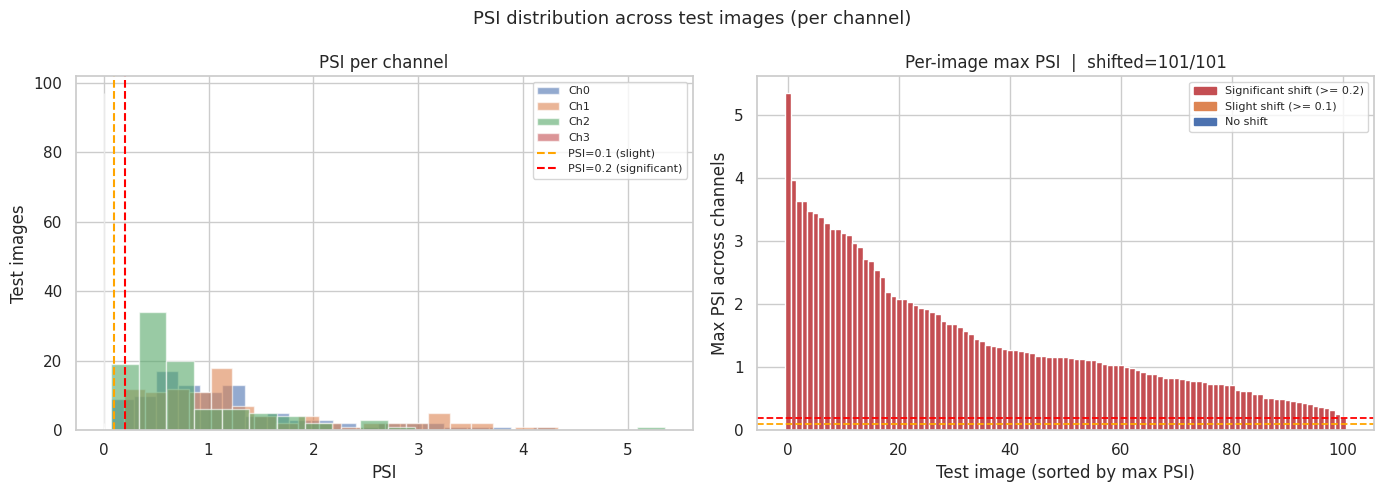

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSI distribution across test images (per channel)', fontsize=13)

# Histogram of PSI values per channel
for ch, color in zip(range(4), CLASS_COLORS):
    axes[0].hist(psi_df[f'psi_ch{ch}'], bins=20, alpha=0.6,
                 label=f'Ch{ch}', color=color, edgecolor='white')
axes[0].axvline(PSI_WARN, color='orange', linestyle='--', lw=1.5, label=f'PSI={PSI_WARN} (slight)')
axes[0].axvline(PSI_CRIT, color='red',    linestyle='--', lw=1.5, label=f'PSI={PSI_CRIT} (significant)')
axes[0].set_xlabel('PSI')
axes[0].set_ylabel('Test images')
axes[0].set_title('PSI per channel')
axes[0].legend(fontsize=8)

# Bar chart of max PSI per test image (sorted)
colors = ['#C44E52' if v >= PSI_CRIT else '#DD8452' if v >= PSI_WARN else '#4C72B0'
          for v in psi_df['psi_max']]
axes[1].bar(range(len(psi_df)), psi_df['psi_max'], color=colors, width=1.0)
axes[1].axhline(PSI_WARN, color='orange', linestyle='--', lw=1.3, label=f'PSI={PSI_WARN}')
axes[1].axhline(PSI_CRIT, color='red',    linestyle='--', lw=1.3, label=f'PSI={PSI_CRIT}')
axes[1].set_xlabel('Test image (sorted by max PSI)')
axes[1].set_ylabel('Max PSI across channels')
axes[1].set_title(f'Per-image max PSI  |  shifted={n_shifted}/{len(psi_df)}')
red_p   = mpatches.Patch(color='#C44E52', label=f'Significant shift (>= {PSI_CRIT})')
orng_p  = mpatches.Patch(color='#DD8452', label=f'Slight shift (>= {PSI_WARN})')
blue_p  = mpatches.Patch(color='#4C72B0', label='No shift')
axes[1].legend(handles=[red_p, orng_p, blue_p], fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_psi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

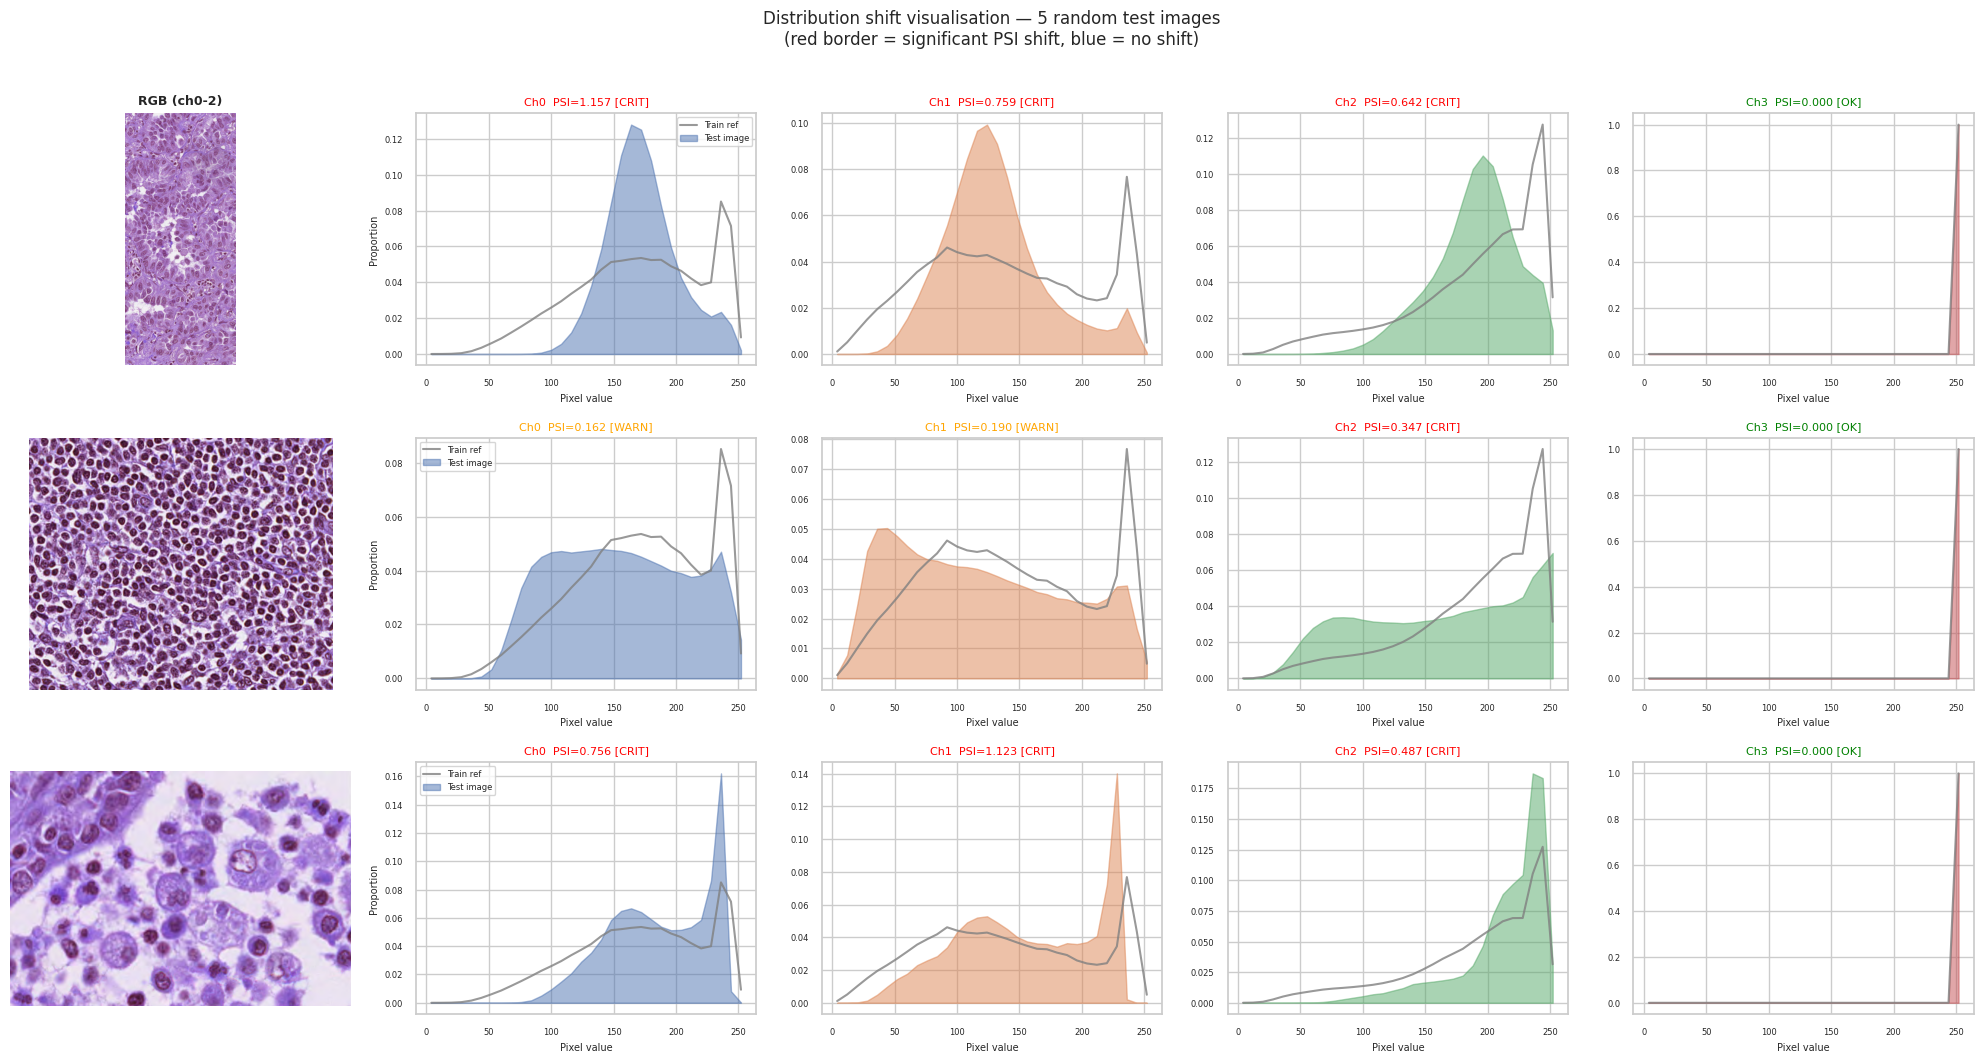

In [20]:
import random

# Pick 5 random images: mix of shifted and non-shifted
shifted_imgs     = psi_df.loc[psi_df['shifted'], 'file_name'].tolist()
non_shifted_imgs = psi_df.loc[~psi_df['shifted'], 'file_name'].tolist()

rng = random.Random(0)
sample_shifted     = rng.sample(shifted_imgs,     min(3, len(shifted_imgs)))
sample_non_shifted = rng.sample(non_shifted_imgs, min(2, len(non_shifted_imgs)))
sample_images      = sample_shifted + sample_non_shifted

bins_edges = np.linspace(0, 256, N_BINS + 1)
bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2

fig, axes = plt.subplots(len(sample_images), 5, figsize=(20, 3.5 * len(sample_images)))
fig.suptitle('Distribution shift visualisation — 5 random test images\n'
             '(red border = significant PSI shift, blue = no shift)',
             fontsize=12, y=1.01)

col_titles = ['RGB (ch0-2)'] + [f'Ch{i} histogram vs train ref' for i in range(4)]
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=9, fontweight='bold')

for row, fname in enumerate(sample_images):
    img       = tifffile.imread(str(TEST_DIR / fname))
    row_info  = psi_df.loc[psi_df['file_name'] == fname].iloc[0]
    is_shift  = row_info['shifted']

    # RGB thumbnail
    rgb = img[..., :3] if img.ndim == 3 else np.stack([img]*3, axis=-1)
    axes[row, 0].imshow(rgb)
    border_color = '#C44E52' if is_shift else '#4C72B0'
    for spine in axes[row, 0].spines.values():
        spine.set_edgecolor(border_color); spine.set_linewidth(3)
    axes[row, 0].set_ylabel(fname[:18], fontsize=7)
    axes[row, 0].axis('off')

    # Per-channel histogram vs reference
    for ch, color in zip(range(4), CLASS_COLORS):
        ax       = axes[row, ch + 1]
        cmp_hist = channel_histogram(img, ch)
        ax.plot(bin_centers, ref_hists[ch], color='gray',  lw=1.5, alpha=0.8, label='Train ref')
        ax.fill_between(bin_centers, cmp_hist, alpha=0.5, color=color, label='Test image')
        ch_psi = row_info[f'psi_ch{ch}']
        severity = ('CRIT' if ch_psi >= PSI_CRIT else 'WARN' if ch_psi >= PSI_WARN else 'OK')
        ax.set_title(f'Ch{ch}  PSI={ch_psi:.3f} [{severity}]', fontsize=8,
                     color='red' if severity == 'CRIT' else 'orange' if severity == 'WARN' else 'green')
        ax.set_xlabel('Pixel value', fontsize=7)
        if ch == 0:
            ax.set_ylabel('Proportion', fontsize=7)
            ax.legend(fontsize=6)
        ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12_distribution_shift_samples.png', dpi=150, bbox_inches='tight')
plt.show()

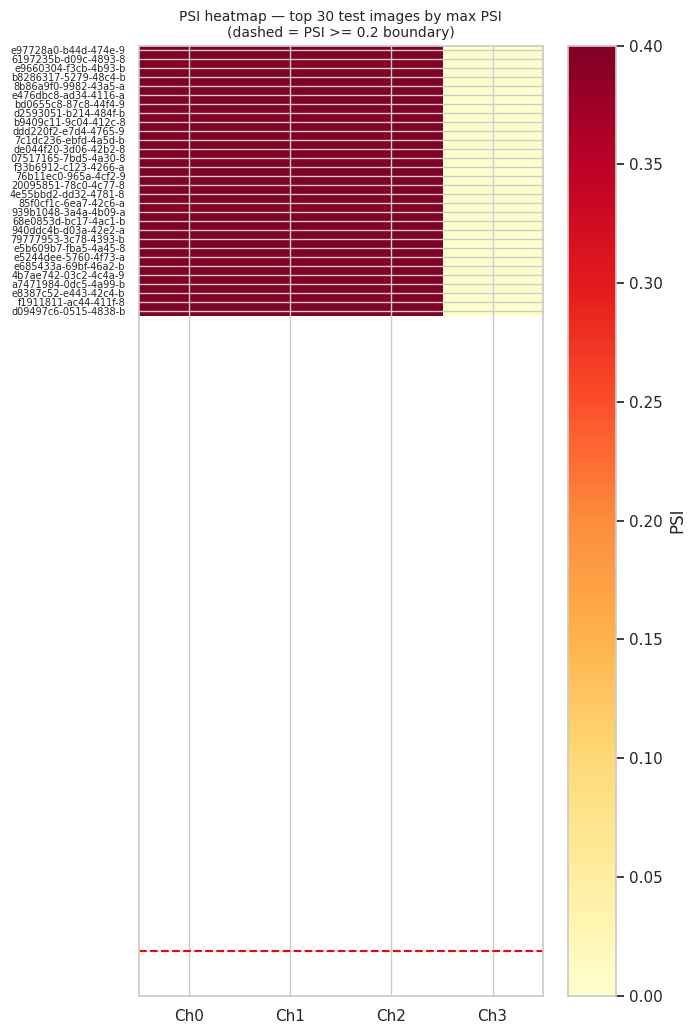


PSI summary across 101 test images:
        psi_ch0   psi_ch1   psi_ch2  psi_ch3   psi_max
count  101.0000  101.0000  101.0000    101.0  101.0000
mean     1.1697    1.3479    0.8102      0.0    1.4561
std      0.8870    0.9924    0.7519      0.0    1.0048
min      0.0745    0.1905    0.0698      0.0    0.2070
25%      0.5602    0.6223    0.3627      0.0    0.7721
50%      0.9267    1.0771    0.5588      0.0    1.1541
75%      1.4501    1.6823    1.0138      0.0    1.9239
max      4.3066    4.3359    5.3473      0.0    5.3473


In [21]:
# PSI heatmap: each row = test image (top 30 by max PSI), each col = channel
top_n  = min(30, len(psi_df))
hm_data = psi_df.head(top_n)[['psi_ch0','psi_ch1','psi_ch2','psi_ch3']].values
hm_labs = psi_df.head(top_n)['file_name'].str[:20].tolist()

fig, ax = plt.subplots(figsize=(7, max(6, top_n * 0.35)))
im = ax.imshow(hm_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.4)
ax.set_xticks(range(4))
ax.set_xticklabels(['Ch0','Ch1','Ch2','Ch3'])
ax.set_yticks(range(top_n))
ax.set_yticklabels(hm_labs, fontsize=7)
plt.colorbar(im, ax=ax, label='PSI')
# Overlay PSI threshold lines
ax.axhline(-0.5 + (psi_df['psi_max'] >= PSI_CRIT).sum() - 0.5,
           color='red', lw=1.5, linestyle='--')
ax.set_title(f'PSI heatmap — top {top_n} test images by max PSI\n'
             f'(dashed = PSI >= {PSI_CRIT} boundary)', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '13_psi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPSI summary across {len(psi_df)} test images:')
print(psi_df[['psi_ch0','psi_ch1','psi_ch2','psi_ch3','psi_max']].describe().round(4))